<a href="https://colab.research.google.com/github/kruthee05/MACHINELEARNING2/blob/main/findS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# FIND-S ALGORITHM FOR SPLICE-JUNCTION GENE SEQUENCES
# ============================================================

# 1. Read the dataset supplied by the user
file_path = "/content/dna.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df.iloc[:, -1].value_counts())


# ------------------------------------------------------------
# 2. Identify target/class column
# ------------------------------------------------------------


target_column = "class"

if target_column not in df.columns:
    # Try to find a likely class column automatically
    possible_targets = ["Class", "target", "Target", "label", "Label"]

    for col in possible_targets:
        if col in df.columns:
            target_column = col
            break

print("\nTarget column:", target_column)


# ------------------------------------------------------------
# 3. Separate attributes and class
# ------------------------------------------------------------

X = df.drop(columns=[target_column])
y = df[target_column]


# ------------------------------------------------------------
# 4. Choose the positive class
# ------------------------------------------------------------

POSITIVE_CLASS = "EI"

# Handle possible lowercase class labels
if POSITIVE_CLASS not in y.astype(str).unique():
    POSITIVE_CLASS = "ei"

print("Positive class:", POSITIVE_CLASS)


# ------------------------------------------------------------
# 5. Find-S Algorithm
# ------------------------------------------------------------

def find_s(X, y, positive_class):
    """
    Find-S algorithm.

    Starts with the most specific hypothesis and
    generalizes it using only positive examples.

    ϕ  -> no value accepted initially
    ?  -> any value accepted
    """

    # Convert all attributes to strings so that
    # categorical/binary values are handled consistently.
    X = X.astype(str)
    y = y.astype(str)

    # Most specific hypothesis
    hypothesis = ["ϕ"] * X.shape[1]

    positive_count = 0

    for index in range(len(X)):

        # Ignore negative examples
        if y.iloc[index] != str(positive_class):
            continue

        positive_count += 1

        example = X.iloc[index].values

        # Process every attribute
        for j in range(len(hypothesis)):

            # First positive example:
            # replace ϕ with its attribute value
            if hypothesis[j] == "ϕ":
                hypothesis[j] = example[j]

            # If existing hypothesis and current example differ,
            # generalize to '?'
            elif hypothesis[j] != example[j]:
                hypothesis[j] = "?"

        # Display hypothesis after each positive example
        print(
            f"After positive example {positive_count}: "
            f"{hypothesis}"
        )

    return hypothesis


# ------------------------------------------------------------
# 6. Run Find-S
# ------------------------------------------------------------

final_hypothesis = find_s(
    X,
    y,
    POSITIVE_CLASS
)


# ------------------------------------------------------------
# 7. Display final hypothesis
# ------------------------------------------------------------

print("\n========================================")
print("FINAL FIND-S HYPOTHESIS")
print("========================================")

for i, value in enumerate(final_hypothesis):
    print(f"{X.columns[i]} : {value}")

Dataset shape: (3186, 181)

Columns:
['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A75', 'A76', 'A77', 'A78', 'A79', 'A80', 'A81', 'A82', 'A83', 'A84', 'A85', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A94', 'A95', 'A96', 'A97', 'A98', 'A99', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A118', 'A119', 'A120', 'A121', 'A122', 'A123', 'A124', 'A125', 'A126', 'A127', 'A128', 'A129', 'A130', 'A131', 'A132', 'A133', 

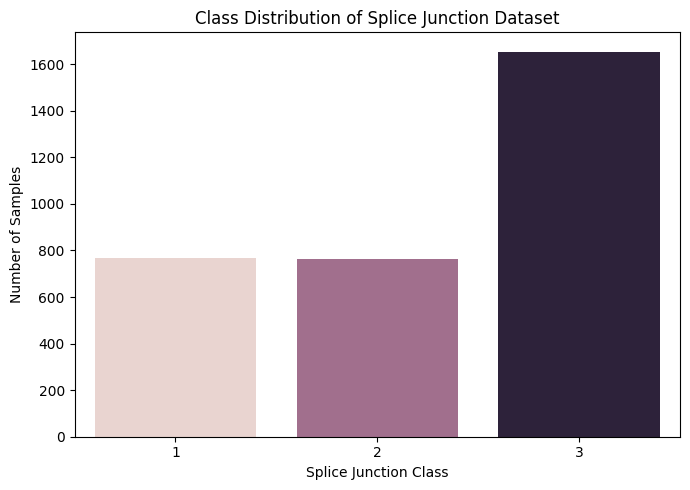

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target_column, hue=target_column, legend=False)

plt.title("Class Distribution of Splice Junction Dataset")
plt.xlabel("Splice Junction Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [ ]:
print("Target column:", target_column)
print("POSITIVE_CLASS:", POSITIVE_CLASS)

print("\nUnique class values:")
print(y.unique())

print("\nClass counts:")
print(y.value_counts())

Target column: class
POSITIVE_CLASS: ei

Unique class values:
[3 1 2]

Class counts:
class
3    1654
1     767
2     765
Name: count, dtype: int64


Positive class: 1
Available classes: [3 1 2]
Positive examples processed: 767


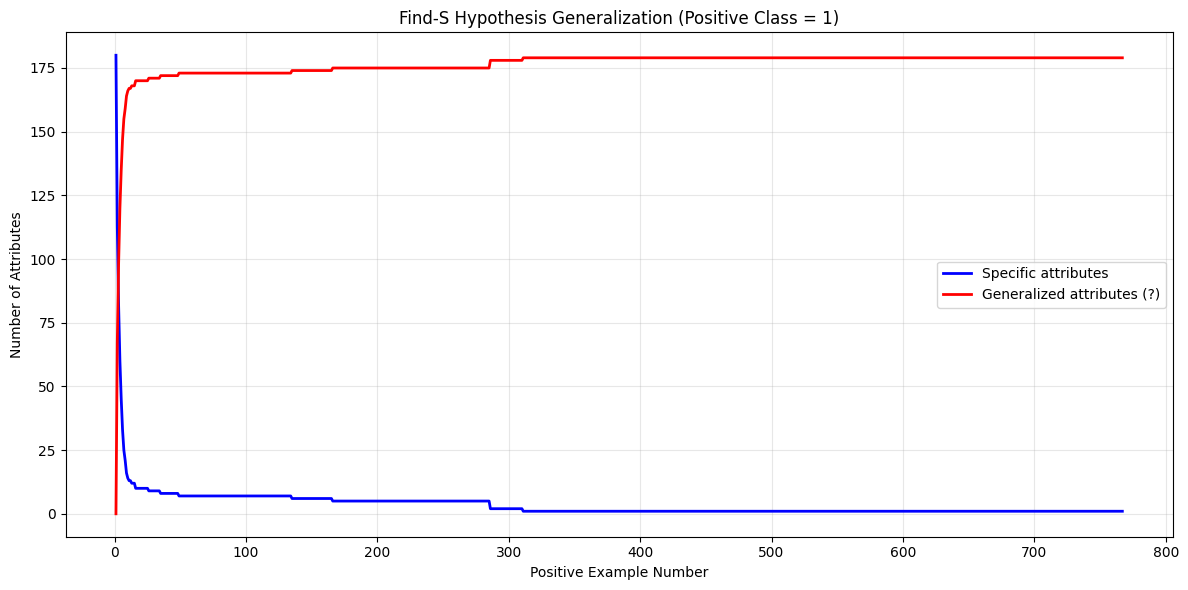


FINAL HYPOTHESIS
Attribute 1: ?
Attribute 2: ?
Attribute 3: ?
Attribute 4: ?
Attribute 5: ?
Attribute 6: ?
Attribute 7: ?
Attribute 8: ?
Attribute 9: ?
Attribute 10: ?
Attribute 11: ?
Attribute 12: ?
Attribute 13: ?
Attribute 14: ?
Attribute 15: ?
Attribute 16: ?
Attribute 17: ?
Attribute 18: ?
Attribute 19: ?
Attribute 20: ?
Attribute 21: ?
Attribute 22: ?
Attribute 23: ?
Attribute 24: ?
Attribute 25: ?
Attribute 26: ?
Attribute 27: ?
Attribute 28: ?
Attribute 29: ?
Attribute 30: ?
Attribute 31: ?
Attribute 32: ?
Attribute 33: ?
Attribute 34: ?
Attribute 35: ?
Attribute 36: ?
Attribute 37: ?
Attribute 38: ?
Attribute 39: ?
Attribute 40: ?
Attribute 41: ?
Attribute 42: ?
Attribute 43: ?
Attribute 44: ?
Attribute 45: ?
Attribute 46: ?
Attribute 47: ?
Attribute 48: ?
Attribute 49: ?
Attribute 50: ?
Attribute 51: ?
Attribute 52: ?
Attribute 53: ?
Attribute 54: ?
Attribute 55: ?
Attribute 56: ?
Attribute 57: ?
Attribute 58: ?
Attribute 59: ?
Attribute 60: ?
Attribute 61: ?
Attribute 62: ?

In [ ]:
import matplotlib.pyplot as plt

# Make sure target values are integers
y = y.astype(int)

POSITIVE_CLASS = 1

print("Positive class:", POSITIVE_CLASS)
print("Available classes:", y.unique())


def find_s_with_history(X, y, positive_class):

    X = X.astype(str)

    # Most specific hypothesis
    hypothesis = ["ϕ"] * X.shape[1]

    history = []
    positive_count = 0

    for i in range(len(X)):

        # Only process positive examples
        if y.iloc[i] != positive_class:
            continue

        positive_count += 1

        example = X.iloc[i].values

        for j in range(len(hypothesis)):

            if hypothesis[j] == "ϕ":
                hypothesis[j] = example[j]

            elif hypothesis[j] != example[j]:
                hypothesis[j] = "?"

        # Save hypothesis after this positive example
        history.append(hypothesis.copy())

    print("Positive examples processed:", positive_count)

    return hypothesis, history


# Run Find-S
final_hypothesis, history = find_s_with_history(
    X,
    y,
    POSITIVE_CLASS
)


# ------------------------------------------------
# Count specific and generalized attributes
# ------------------------------------------------

specific_counts = []
generalized_counts = []

for h in history:

    specific = sum(
        1 for x in h
        if x not in ["?", "ϕ"]
    )

    generalized = sum(
        1 for x in h
        if x == "?"
    )

    specific_counts.append(specific)
    generalized_counts.append(generalized)


# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(history) + 1),
    specific_counts,
    label="Specific attributes",
    color="blue",
    linewidth=2
)

plt.plot(
    range(1, len(history) + 1),
    generalized_counts,
    label="Generalized attributes (?)",
    color="red",
    linewidth=2
)

plt.xlabel("Positive Example Number")
plt.ylabel("Number of Attributes")
plt.title(
    "Find-S Hypothesis Generalization "
    f"(Positive Class = {POSITIVE_CLASS})"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# Final hypothesis
# ------------------------------------------------

print("\nFINAL HYPOTHESIS")
print("=" * 50)

for i, value in enumerate(final_hypothesis):
    print(f"Attribute {i+1}: {value}")

In [ ]:
print(df[target_column].value_counts().sort_index())

class
1     767
2     765
3    1654
Name: count, dtype: int64


In [ ]:
print("========== FIND-S RESULT ==========")
print("Positive class:", POSITIVE_CLASS)
print("Number of positive examples:", len(history))
print("Number of attributes:", len(final_hypothesis))

print("\nFinal Hypothesis:")
print("<" + ", ".join(final_hypothesis) + ">")

========== FIND-S RESULT ==========
Positive class: 1
Number of positive examples: 767
Number of attributes: 180

Final Hypothesis:
<?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, 0, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?>
